In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('shopping_behavior_updated.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.shape

(3900, 18)

In [4]:
df.isna().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [84]:
numeric_cols= df.select_dtypes(include=['int64', 'object']).columns
cat_cols= df.select_dtypes(include=['float64']).columns

print('Numerical columns:',numeric_cols.tolist())
print('Categorical columns:' , cat_cols.tolist())

Numerical columns: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']
Categorical columns: ['Review Rating']


<function matplotlib.pyplot.show(close=None, block=None)>

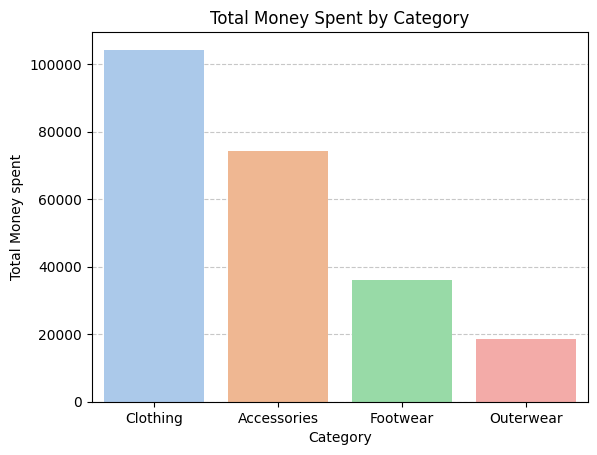

In [7]:
spent_by_cat= df.groupby('Category')['Purchase Amount (USD)'].sum().head(7).sort_values(ascending=False)

ax=sns.barplot(y=spent_by_cat.values, x=spent_by_cat.index, palette='pastel', legend=False, hue= spent_by_cat.index)
ax.set_axisbelow(True)
ax.grid(linestyle='--', alpha=0.7, axis='y')
plt.title('Total Money Spent by Category')
ax.set_ylabel('Total Money spent')
plt.show

In [8]:
df.groupby(['Category','Season'])['Purchase Amount (USD)'].sum()

Category     Season
Accessories  Fall      19874
             Spring    17007
             Summer    19028
             Winter    18291
Clothing     Fall      26220
             Spring    27692
             Summer    23078
             Winter    27274
Footwear     Fall       8665
             Spring     9555
             Summer     9393
             Winter     8480
Outerwear    Fall       5259
             Spring     4425
             Summer     4278
             Winter     4562
Name: Purchase Amount (USD), dtype: int64

In [9]:
top_states=df.groupby('Location')['Purchase Amount (USD)'].sum().head(10).sort_values(ascending=False)

<function matplotlib.pyplot.show(close=None, block=None)>

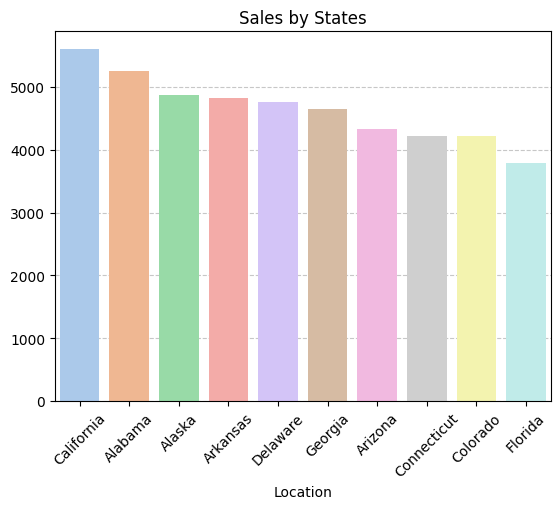

In [11]:
ax=sns.barplot(y=top_states.values, x=top_states.index, palette='pastel', hue=top_states.index)
plt.title('Sales by States')
ax.set_axisbelow(True)
ax.grid(alpha=0.7, linestyle='--', axis='y')
plt.xticks(rotation=45)
plt.show

In [12]:
df['Age'].min()

np.int64(18)

In [13]:
bins=[18,25,35,45,55,65,70]
labels=['18-25', '26-35', '36-45','46-55','56-65','66-70']

df['Age_group']=pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age_group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,56-65
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,18-25
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,46-55
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,18-25
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,46-55


<function matplotlib.pyplot.show(close=None, block=None)>

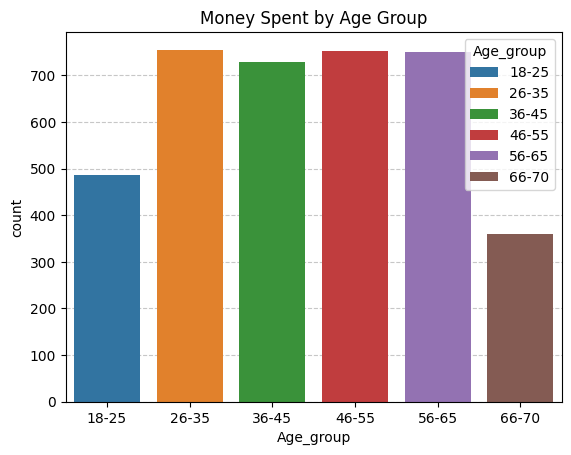

In [14]:
ax=sns.countplot(x=df['Age_group'], palette='tab10', hue=df['Age_group'] )
ax.set_axisbelow(True)
plt.grid(alpha=0.7, linestyle='--', axis='y')
plt.title('Money Spent by Age Group')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

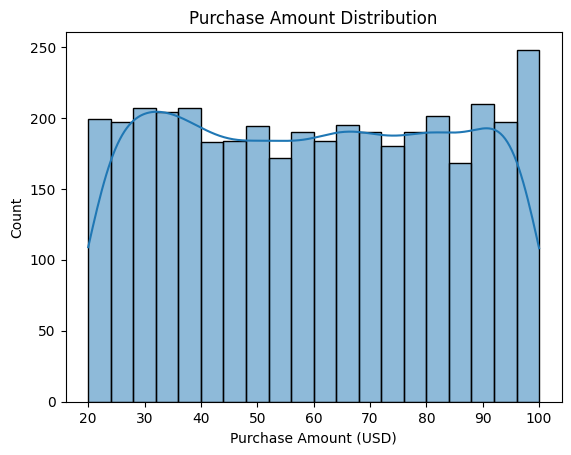

In [15]:
ax=sns.histplot(df['Purchase Amount (USD)'], kde=True, bins=20)

plt.title('Purchase Amount Distribution')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

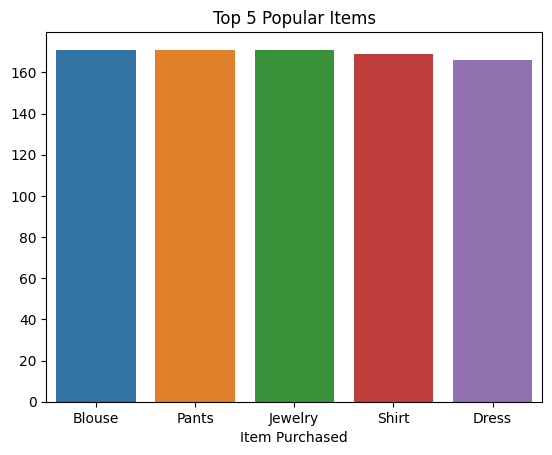

In [17]:
top_items= df['Item Purchased'].value_counts().sort_values(ascending=False).head(5)
sns.barplot(x=top_items.index, y=top_items.values, palette='tab10', hue=top_items.index)
plt.title('Top 5 Popular Items')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

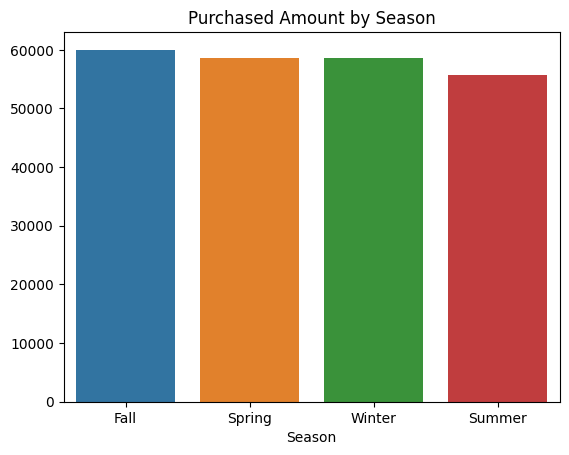

In [18]:
total_seasons= df.groupby('Season')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
sns.barplot(x=total_seasons.index, y= total_seasons.values, palette='tab10', hue=total_seasons.index)
plt.title('Purchased Amount by Season')
plt.show

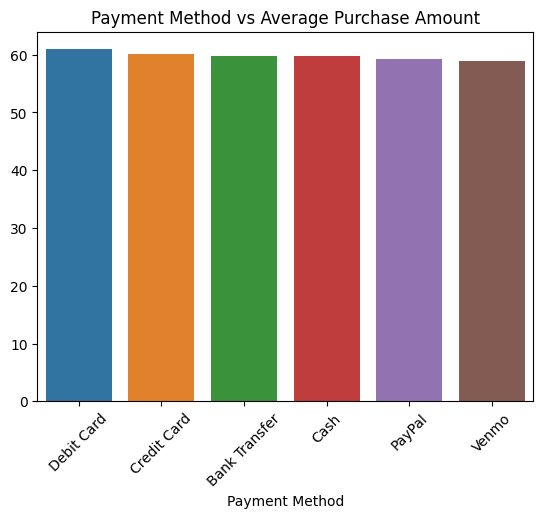

In [20]:
avg_payment= df.groupby('Payment Method')['Purchase Amount (USD)'].mean().sort_values(ascending=False)
sns.barplot(x=avg_payment.index, y=avg_payment.values, palette='tab10', hue=avg_payment.index)
plt.title('Payment Method vs Average Purchase Amount')
plt.xticks(rotation=45)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

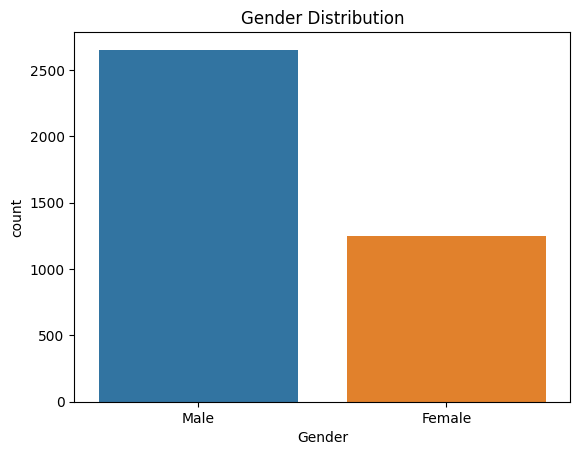

In [21]:
sns.countplot(x=df['Gender'], palette='tab10', hue=df['Gender'])
plt.title('Gender Distribution')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

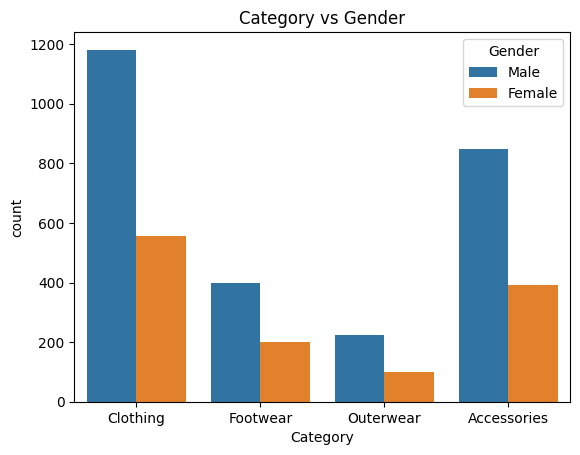

In [118]:
sns.countplot(x=df['Category'], hue=df['Gender'])
plt.title('Category vs Gender')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

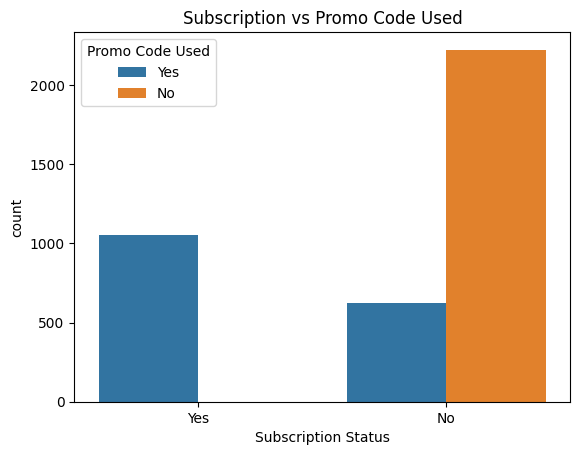

In [119]:
sns.countplot(x=df['Subscription Status'], hue=df['Promo Code Used'])
plt.title('Subscription vs Promo Code Used')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

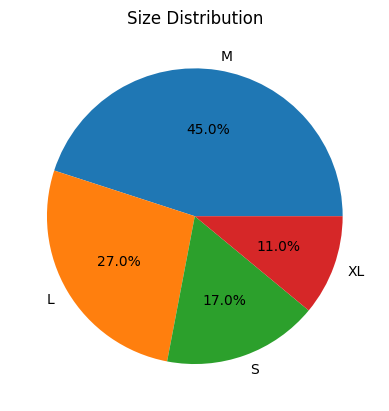

In [129]:
plt.pie(df['Size'].value_counts(), labels=df['Size'].value_counts().index, autopct='%1.1f%%')
plt.title('Size Distribution')
plt.show